In [6]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score, log_loss
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
print(f"LightGBM version: {lgb.__version__}")


LightGBM version: 4.6.0


In [2]:
## Loading the data
train_df  = pd.read_csv('Train.csv')
prior_df  = pd.read_csv('Prior.csv')
test_df   = pd.read_csv('Test.csv')

# Combine Train + Prior for maximum training data
all_train_df = pd.concat([train_df, prior_df], ignore_index=True)

print(f"Train rows: {len(train_df):,}  |  Prior rows: {len(prior_df):,}  |  Combined: {len(all_train_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"\nColumns: {list(train_df.columns)}")


Train rows: 13,536  |  Prior rows: 44,882  |  Combined: 58,418
Test rows:  5,621

Columns: ['ID', 'farmer_name', 'training_day', 'gender', 'registration', 'age', 'group_name', 'belong_to_cooperative', 'county', 'subcounty', 'ward', 'adopted_within_07_days', 'adopted_within_90_days', 'adopted_within_120_days', 'has_topic_trained_on', 'trainer', 'topics_list']


In [3]:
## Feature Engineering
def safe_parse_list(s):
    """Parse Python list strings safely; return empty list on failure."""
    if pd.isna(s):
        return []
    try:
        result = ast.literal_eval(str(s))
        if isinstance(result, list):
            return result
        return [result]
    except Exception:
        return []

def engineer_features(df):
    df = df.copy()

    # --- Date features ---
    df['training_day'] = pd.to_datetime(df['training_day'], errors='coerce')
    df['day_of_week']  = df['training_day'].dt.dayofweek        # 0=Mon
    df['week_of_year'] = df['training_day'].dt.isocalendar().week.astype(float)
    df['month']        = df['training_day'].dt.month

    # --- Topics features ---
    # topics_list is a list-of-lists (sessions × topics per session)
    def flatten_topics(s):
        outer = safe_parse_list(s)
        topics = []
        for item in outer:
            if isinstance(item, list):
                topics.extend(item)
            else:
                topics.append(item)
        return topics

    df['topics_flat']    = df['topics_list'].apply(flatten_topics)
    df['n_topics']       = df['topics_flat'].apply(len)
    df['n_sessions']     = df['topics_list'].apply(lambda s: len(safe_parse_list(s)))
    df['n_unique_topics']= df['topics_flat'].apply(lambda t: len(set(t)))

    # Poultry-related topics flag (common trigger for adoption)
    poultry_kw = ['Poultry', 'poultry', 'Chicken', 'chicken', 'Layer', 'layer']
    df['has_poultry_topic'] = df['topics_flat'].apply(
        lambda ts: int(any(any(kw in t for kw in poultry_kw) for t in ts))
    )

    # Dairy-related topics flag
    dairy_kw = ['Dairy', 'dairy', 'Milk', 'milk', 'Calf', 'calf', 'Cow', 'cow']
    df['has_dairy_topic'] = df['topics_flat'].apply(
        lambda ts: int(any(any(kw in t for kw in dairy_kw) for t in ts))
    )

    df.drop(columns=['topics_flat'], inplace=True)
    return df

all_train_df = engineer_features(all_train_df)
test_df      = engineer_features(test_df)

print("Feature engineering done.")
print(f"New feature columns: day_of_week, week_of_year, month, n_topics, n_sessions, n_unique_topics, has_poultry_topic, has_dairy_topic")


Feature engineering done.
New feature columns: day_of_week, week_of_year, month, n_topics, n_sessions, n_unique_topics, has_poultry_topic, has_dairy_topic


In [4]:
## Define targets and features
TARGET_COLS = [
    'adopted_within_07_days',
    'adopted_within_90_days',
    'adopted_within_120_days',
]

for t in TARGET_COLS:
    all_train_df[t] = all_train_df[t].astype(int)

print("Target positive rates:")
for t in TARGET_COLS:
    rate = all_train_df[t].mean()
    print(f"  {t}: {rate:.3f}  ({all_train_df[t].sum()} / {len(all_train_df)})")


Target positive rates:
  adopted_within_07_days: 0.014  (817 / 58418)
  adopted_within_90_days: 0.030  (1742 / 58418)
  adopted_within_120_days: 0.041  (2389 / 58418)


In [5]:
## Define feature columns
categorical_features = [
    'gender',
    'registration',
    'age',
    'trainer',
    'belong_to_cooperative',
    'county',
    'subcounty',
    'ward',
]

numeric_features = [
    'day_of_week',
    'week_of_year',
    'month',
    'n_topics',
    'n_sessions',
    'n_unique_topics',
    'has_poultry_topic',
    'has_dairy_topic',
]

feature_cols = categorical_features + numeric_features
print(f"Total features: {len(feature_cols)}")
print("  Categorical:", categorical_features)
print("  Numeric:    ", numeric_features)


Total features: 16
  Categorical: ['gender', 'registration', 'age', 'trainer', 'belong_to_cooperative', 'county', 'subcounty', 'ward']
  Numeric:     ['day_of_week', 'week_of_year', 'month', 'n_topics', 'n_sessions', 'n_unique_topics', 'has_poultry_topic', 'has_dairy_topic']


In [7]:
## Dataset summary
X_train = all_train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

# Quick look at missing values
miss = X_train.isnull().sum()
print("\nMissing values in train features:")
print(miss[miss > 0] if miss.any() else "  None")


X_train shape: (58418, 16)
X_test  shape: (5621, 16)

Missing values in train features:
  None


In [8]:
## Encode categoricals → LightGBM-friendly integer codes
# LightGBM can handle categoricals natively (no OHE needed)
# We just label-encode them; LightGBM treats them as categorical internally.

from sklearn.preprocessing import OrdinalEncoder

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord',     OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, categorical_features),
    ('num', num_pipe, numeric_features),
], remainder='drop')

# Column order after transform (cat first, then num)
cat_indices = list(range(len(categorical_features)))   # positions of categorical cols

def make_lgb_model(pos_weight: float):
    """LightGBM model using `scale_pos_weight` for imbalance."""
    return lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=pos_weight,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )

print("Preprocessor and LightGBM factory ready.")


Preprocessor and LightGBM factory ready.


In [9]:
## Cross-validation — OOF predictions for all 3 targets
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def recall_at_k(y_true, y_scores, k_frac):
    k = int(np.ceil(len(y_true) * k_frac))
    order = np.argsort(-np.asarray(y_scores))
    topk  = order[:k]
    return float(np.asarray(y_true)[topk].sum() / np.asarray(y_true).sum()) if np.asarray(y_true).sum() > 0 else np.nan

# Pre-transform features once for all CV runs
X_train_np  = preprocessor.fit_transform(X_train)
X_test_np   = preprocessor.transform(X_test)

oof_results = []
oof_probas  = {}   # store for stacking / later analysis

for target in TARGET_COLS:
    y = all_train_df[target].values
    pos_w = (y == 0).sum() / max((y == 1).sum(), 1)
    oof_proba = np.zeros(len(y))

    for tr_idx, va_idx in cv.split(X_train_np, y):
        clf = make_lgb_model(pos_w)
        clf.fit(
            X_train_np[tr_idx], y[tr_idx],
            categorical_feature=cat_indices,
        )
        oof_proba[va_idx] = clf.predict_proba(X_train_np[va_idx])[:, 1]

    oof_probas[target] = oof_proba

    pr_auc  = average_precision_score(y, oof_proba)
    roc_auc = roc_auc_score(y, oof_proba)
    ll      = log_loss(y, oof_proba)
    oof_results.append({
        'target':    target,
        'PR AUC':    round(pr_auc, 4),
        'ROC AUC':   round(roc_auc, 4),
        'LogLoss':   round(ll,     4),
        'Recall@5%': round(recall_at_k(y, oof_proba, 0.05),  4),
        'Recall@10%':round(recall_at_k(y, oof_proba, 0.10), 4),
        'Recall@20%':round(recall_at_k(y, oof_proba, 0.20), 4),
    })
    print(f"[{target}]  PR-AUC={pr_auc:.4f}  ROC-AUC={roc_auc:.4f}  LogLoss={ll:.4f}")

oof_df = pd.DataFrame(oof_results)
display(oof_df)


[adopted_within_07_days]  PR-AUC=0.2949  ROC-AUC=0.9633  LogLoss=0.1628
[adopted_within_90_days]  PR-AUC=0.3698  ROC-AUC=0.9449  LogLoss=0.2327
[adopted_within_120_days]  PR-AUC=0.3840  ROC-AUC=0.9308  LogLoss=0.2805


,target,PR AUC,ROC AUC,LogLoss,Recall@5%,Recall@10%,Recall@20%
0,adopted_within_07_days,0.2949,0.9633,0.1628,0.6744,0.9461,0.9829
1,adopted_within_90_days,0.3698,0.9449,0.2327,0.5465,0.7681,0.9552
2,adopted_within_120_days,0.3840,0.9308,0.2805,0.4642,0.6739,0.9071


In [10]:
## Train final models on ALL training data and predict on test
models = {}
pred_probas = {}

for target in TARGET_COLS:
    y = all_train_df[target].values
    pos_w = (y == 0).sum() / max((y == 1).sum(), 1)
    clf = make_lgb_model(pos_w)
    clf.fit(X_train_np, y, categorical_feature=cat_indices)
    models[target]      = clf
    pred_probas[target] = clf.predict_proba(X_test_np)[:, 1]
    print(f"[{target}]  pos_weight={pos_w:.1f}  test preds: min={pred_probas[target].min():.3f}  max={pred_probas[target].max():.3f}  mean={pred_probas[target].mean():.3f}")


[adopted_within_07_days]  pos_weight=70.5  test preds: min=0.000  max=0.999  mean=0.018
[adopted_within_90_days]  pos_weight=32.5  test preds: min=0.000  max=0.998  mean=0.024
[adopted_within_120_days]  pos_weight=23.5  test preds: min=0.000  max=0.997  mean=0.043


## Make the prediction


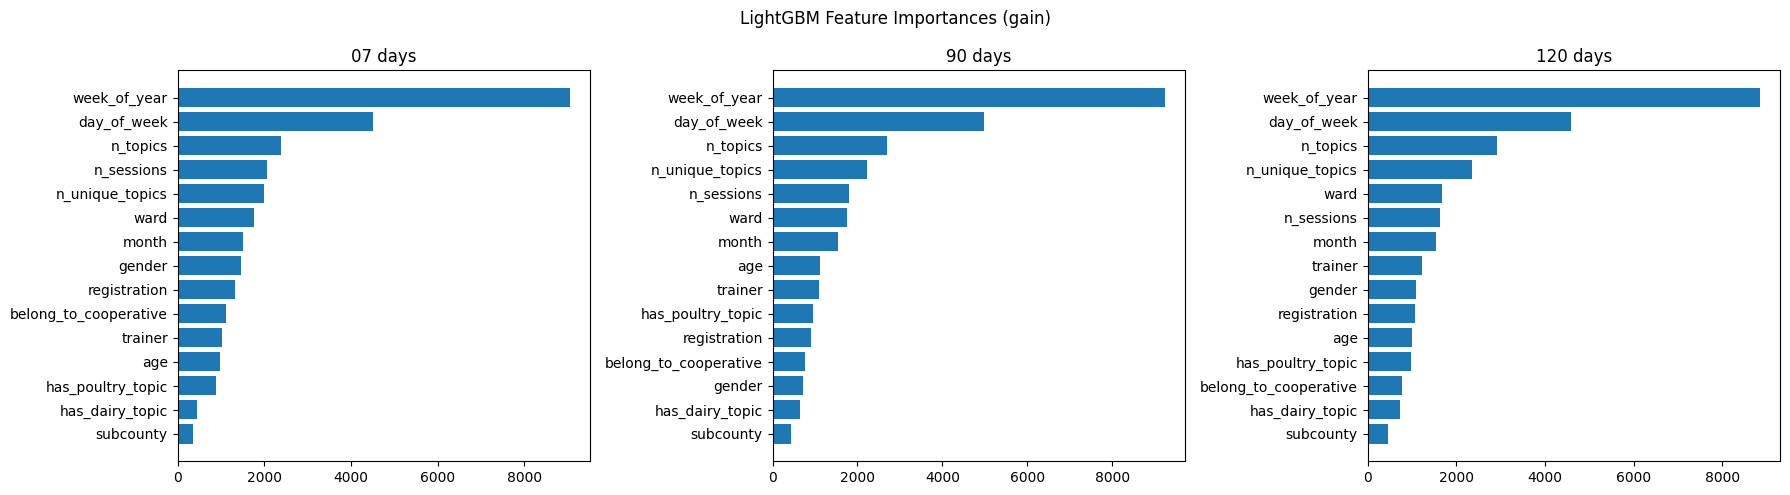

In [11]:
## Feature importances
feat_names = categorical_features + numeric_features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, target in zip(axes, TARGET_COLS):
    clf = models[target]
    imp = clf.feature_importances_
    idx = np.argsort(imp)[-15:]
    ax.barh([feat_names[i] for i in idx], imp[idx])
    ax.set_title(target.replace('adopted_within_', '').replace('_days', ' days'))
plt.suptitle('LightGBM Feature Importances (gain)')
plt.tight_layout()
plt.show()


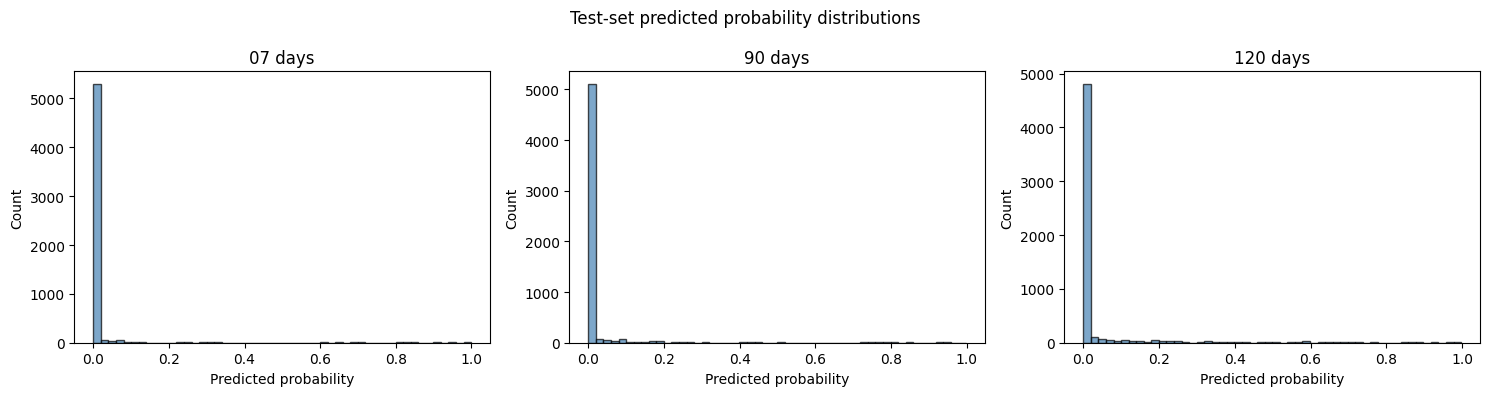

In [12]:
## Prediction distribution on test set
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axes, TARGET_COLS):
    p = pred_probas[target]
    ax.hist(p, bins=50, edgecolor='k', alpha=0.7, color='steelblue')
    ax.set_title(target.replace('adopted_within_', '').replace('_days', ' days'))
    ax.set_xlabel('Predicted probability')
    ax.set_ylabel('Count')
plt.suptitle('Test-set predicted probability distributions')
plt.tight_layout()
plt.show()


In [13]:
## OOF metrics summary
print("\nOut-of-Fold evaluation summary (5-fold CV on full train+prior data):")
display(oof_df)



Out-of-Fold evaluation summary (5-fold CV on full train+prior data):


,target,PR AUC,ROC AUC,LogLoss,Recall@5%,Recall@10%,Recall@20%
0,adopted_within_07_days,0.2949,0.9633,0.1628,0.6744,0.9461,0.9829
1,adopted_within_90_days,0.3698,0.9449,0.2327,0.5465,0.7681,0.9552
2,adopted_within_120_days,0.3840,0.9308,0.2805,0.4642,0.6739,0.9071


In [14]:
## Build and save submission
ss = pd.read_csv('SampleSubmission.csv')

ss['Target_07_AUC']      = pred_probas['adopted_within_07_days']
ss['Target_90_AUC']      = pred_probas['adopted_within_90_days']
ss['Target_120_AUC']     = pred_probas['adopted_within_120_days']
ss['Target_07_LogLoss']  = pred_probas['adopted_within_07_days']
ss['Target_90_LogLoss']  = pred_probas['adopted_within_90_days']
ss['Target_120_LogLoss'] = pred_probas['adopted_within_120_days']

ss.to_csv('submission.csv', index=False)

expected_cols = ['ID', 'Target_07_AUC', 'Target_90_AUC', 'Target_120_AUC',
                 'Target_07_LogLoss', 'Target_90_LogLoss', 'Target_120_LogLoss']
assert list(ss.columns) == expected_cols
assert len(ss) == len(test_df)
print(f"submission.csv saved — {len(ss)} rows, columns: {list(ss.columns)}")
ss.head()


submission.csv saved — 5621 rows, columns: ['ID', 'Target_07_AUC', 'Target_90_AUC', 'Target_120_AUC', 'Target_07_LogLoss', 'Target_90_LogLoss', 'Target_120_LogLoss']


,ID,Target_07_AUC,Target_90_AUC,Target_120_AUC,Target_07_LogLoss,Target_90_LogLoss,Target_120_LogLoss
0,ID_LEG1GM,0.000025,0.008373,0.005738,0.000025,0.008373,0.005738
1,ID_1UKOKW,0.000014,0.000031,0.000025,0.000014,0.000031,0.000025
2,ID_U5H2YK,0.238583,0.162033,0.197903,0.238583,0.162033,0.197903
3,ID_55957A,0.134713,0.078731,0.194054,0.134713,0.078731,0.194054
4,ID_N1AC0A,0.000011,0.000012,0.000016,0.000011,0.000012,0.000016


In [15]:
## Done — submission.csv is ready to upload to Zindi
print("Pipeline complete.")
print(f"  OOF ROC AUC (07d):  {oof_df.loc[0,'ROC AUC']}")
print(f"  OOF ROC AUC (90d):  {oof_df.loc[1,'ROC AUC']}")
print(f"  OOF ROC AUC (120d): {oof_df.loc[2,'ROC AUC']}")
print("\nUpload submission.csv to Zindi.")


Pipeline complete.
  OOF ROC AUC (07d):  0.9633
  OOF ROC AUC (90d):  0.9449
  OOF ROC AUC (120d): 0.9308

Upload submission.csv to Zindi.
